# The Rebalance Lottery \U0001F3B0
### Same strategy, same data, same rules. Different Tuesday.

![Signal: Confirmed](https://img.shields.io/badge/Signal-Confirmed-2ea44f?style=flat-square)
![Tradability: Useful](https://img.shields.io/badge/Tradability-Useful-2ea44f?style=flat-square)

Two people read the same paper and implement the same rule. One rebalances on the first of the
month, the other on the fifteenth. Twenty years later one of them has substantially more money
than the other, and neither did anything differently.

> \U0001F4D3 **This is the plain-language layer.** The mechanism, the period sweep and the fix
> are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Does the rebalance day matter? | For a selection rule, enormously. |
| How much? | More than the strategy's whole edge. |
| Is it avoidable? | Yes, completely, and cheaply. |
| Does anyone do it? | Almost nobody. |

## 1 · The experiment

In [2]:
from lottery import data, strategy as st

px_all = data.load_prices()
universe = [t for t in data.UNIVERSE if t in px_all.columns]
px = px_all[universe].dropna()
cash = px_all[data.CASH].pct_change().reindex(px.index).fillna(0.0)
mom_rule = lambda: st.momentum_rule(126, 3)
print(f"as-of {data.AS_OF} | {len(universe)} assets, "
      f"{px.index[0].date()} -> {px.index[-1].date()} ({len(px) / 252:.1f} years)")
print(f"rule: hold the 3 best 126-day performers, rebalance every 21 sessions")
print(f"-> 21 possible offsets, all of them equally defensible")

as-of 2026-06-30 | 10 assets, 2007-01-03 -> 2026-06-30 (19.5 years)
rule: hold the 3 best 126-day performers, rebalance every 21 sessions
-> 21 possible offsets, all of them equally defensible


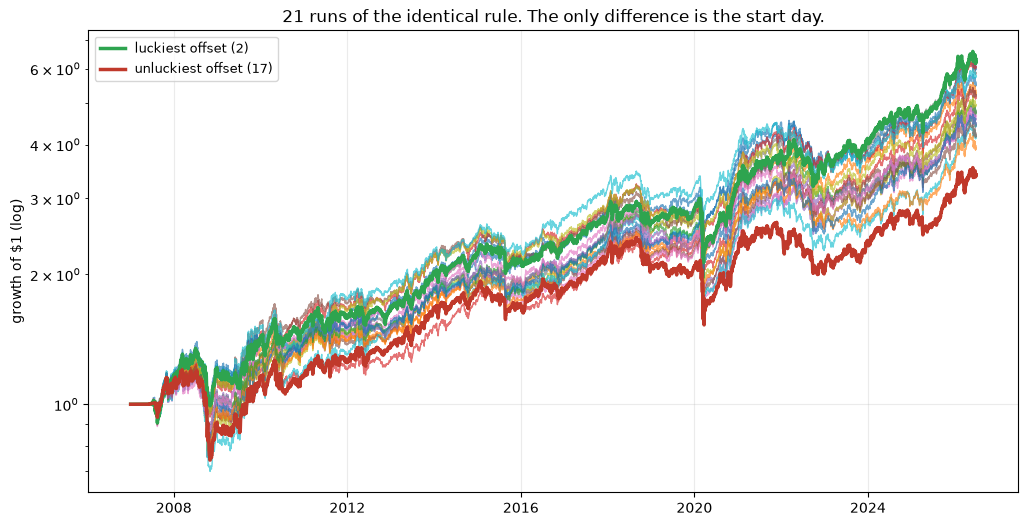

luckiest ended at $6.30, unluckiest at $3.41 (1.85x)


In [3]:
curves = st.variant_curves(px, mom_rule(), period=21, cost_bps=5.0, cash=cash)
fig, ax = plt.subplots(figsize=(12, 6))
for off in curves.columns:
    ax.plot(curves.index, curves[off], lw=1.0, alpha=0.65)
best = curves.iloc[-1].idxmax()
worst = curves.iloc[-1].idxmin()
ax.plot(curves.index, curves[best], lw=2.5, color="#2ea44f",
        label=f"luckiest offset ({best})")
ax.plot(curves.index, curves[worst], lw=2.5, color="#c0392b",
        label=f"unluckiest offset ({worst})")
ax.set_yscale("log"); ax.set_ylabel("growth of $1 (log)"); ax.legend(fontsize=9)
ax.set_title("21 runs of the identical rule. The only difference is the start day.")
plt.show()
print(f"luckiest ended at ${curves[best].iloc[-1]:.2f}, "
      f"unluckiest at ${curves[worst].iloc[-1]:.2f} "
      f"({curves[best].iloc[-1] / curves[worst].iloc[-1]:.2f}x)")

> \U0001F52C **For the quants.** Nobody chose these offsets. They are all equally defensible, and
> a backtest picks one silently. The spread between them is a standard error the reader never
> sees.

## 2 · The numbers

           n   cagr    vol  sharpe  max_dd  final  turnover_per_year
offset                                                              
0       4903 0.0924 0.1486  0.6695 -0.2504 5.5812             6.6573
1       4903 0.0899 0.1490  0.6527 -0.2635 5.3420             6.5557
2       4903 0.0992 0.1488  0.7106 -0.2905 6.2997             6.3232
3       4903 0.0886 0.1550  0.6256 -0.3849 5.2129             6.5004
4       4903 0.0837 0.1554  0.5959 -0.3351 4.7816             6.2661
5       4903 0.0887 0.1542  0.6289 -0.3974 5.2258             5.8617
6       4903 0.0825 0.1538  0.5934 -0.3526 4.6798             6.5276
7       4903 0.0952 0.1601  0.6486 -0.4078 5.8667             6.2860
8       4903 0.0799 0.1540  0.5768 -0.3503 4.4610             6.2650
9       4903 0.0767 0.1563  0.5517 -0.4017 4.2141             6.4744
10      4903 0.0973 0.1474  0.7038 -0.3122 6.0845             6.2889
11      4903 0.0735 0.1558  0.5335 -0.3643 3.9717             6.3879
12      4903 0.0840 0.1573  0.5920

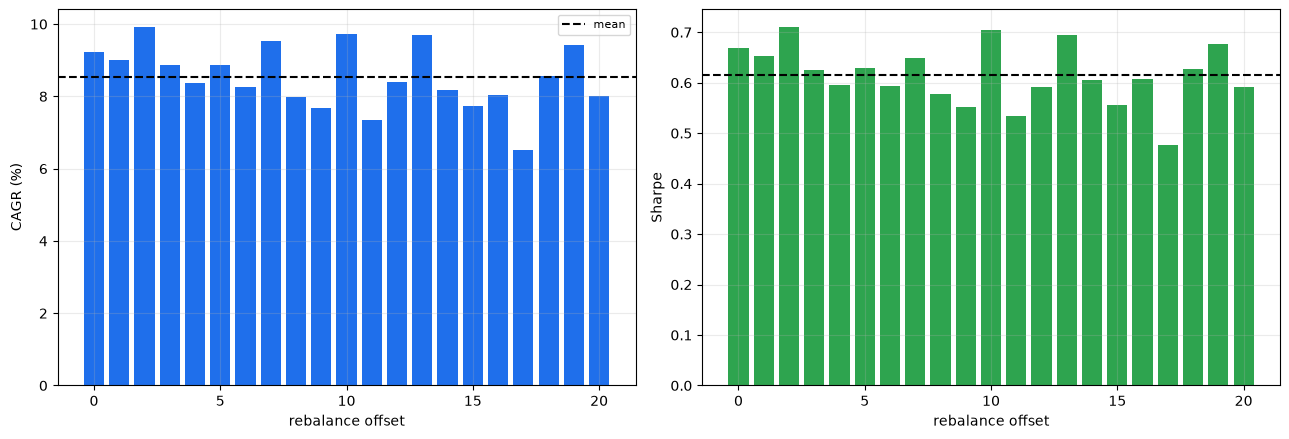

In [4]:
v = st.run_variants(px, mom_rule(), 21, 5.0, cash)
print(v.round(4).to_string())
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(v.index, v["cagr"] * 100, color="#1f6feb")
axes[0].axhline(v["cagr"].mean() * 100, color="k", ls="--", lw=1.5, label="mean")
axes[0].set_xlabel("rebalance offset"); axes[0].set_ylabel("CAGR (%)")
axes[0].legend(fontsize=8)
axes[1].bar(v.index, v["sharpe"], color="#2ea44f")
axes[1].axhline(v["sharpe"].mean(), color="k", ls="--", lw=1.5)
axes[1].set_xlabel("rebalance offset"); axes[1].set_ylabel("Sharpe")
plt.tight_layout(); plt.show()

## 3 · Compared with the edge it is supposed to demonstrate

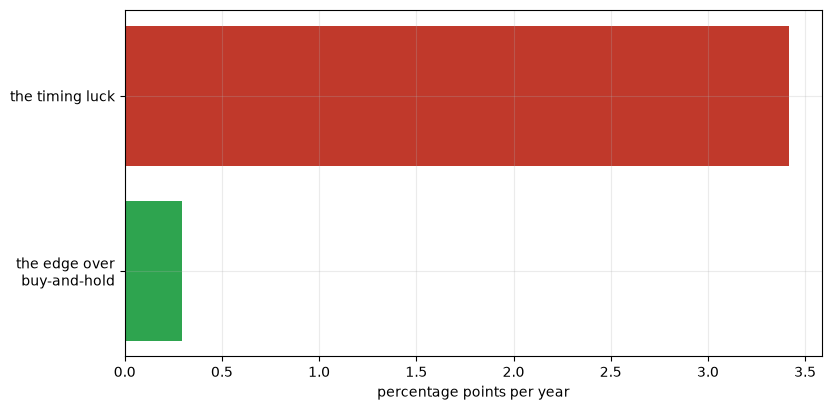

edge:  +0.29%/yr
luck:  3.42% spread
62% of the offsets beat buy-and-hold; 38% did not


In [5]:
equal = px.pct_change().mean(axis=1).fillna(0.0)
bench = float((1 + equal).prod() ** (252 / len(equal)) - 1)
lv = st.luck_vs_signal(v, bench)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(["the edge over\nbuy-and-hold", "the timing luck"],
        [lv["mean_edge"] * 100, lv["luck_spread"] * 100],
        color=["#2ea44f", "#c0392b"])
ax.set_xlabel("percentage points per year")
plt.show()
print(f"edge:  {lv['mean_edge']:+.2%}/yr")
print(f"luck:  {lv['luck_spread']:.2%} spread")
print(f"{lv['share_beating_benchmark']:.0%} of the offsets beat buy-and-hold; "
      f"{1 - lv['share_beating_benchmark']:.0%} did not")

## 4 · Why it happens

The clue is in what happens when the rule *doesn't* choose between assets.

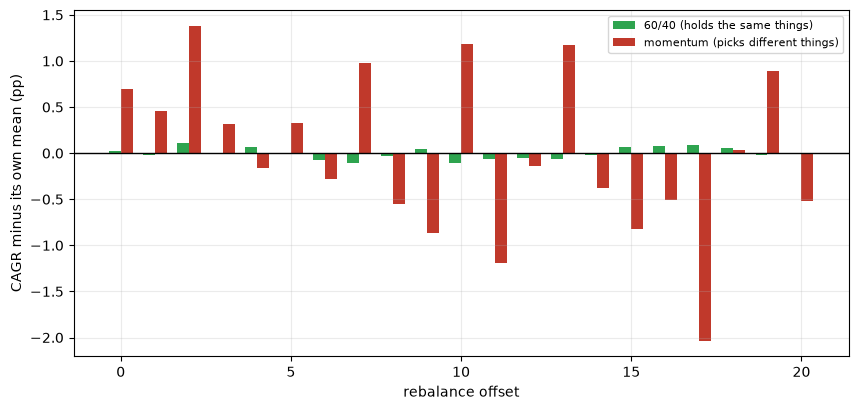

60/40 spread:    0.22%
momentum spread: 3.42%


In [6]:
fw = st.run_variants(px, st.fixed_weight_rule(px, {data.EQUITY: 0.6, data.BONDS: 0.4}),
                     21, 5.0, cash)
fig, ax = plt.subplots(figsize=(10, 4.5))
w = 0.35
ax.bar(np.arange(len(fw)) - w / 2, (fw["cagr"] - fw["cagr"].mean()) * 100, w,
       label="60/40 (holds the same things)", color="#2ea44f")
ax.bar(np.arange(len(v)) + w / 2, (v["cagr"] - v["cagr"].mean()) * 100, w,
       label="momentum (picks different things)", color="#c0392b")
ax.axhline(0, color="k", lw=1)
ax.set_xlabel("rebalance offset"); ax.set_ylabel("CAGR minus its own mean (pp)")
ax.legend(fontsize=8)
plt.show()
print(f"60/40 spread:    {fw['cagr'].max() - fw['cagr'].min():.2%}")
print(f"momentum spread: {v['cagr'].max() - v['cagr'].min():.2%}")

A 60/40 rebalanced on the 3rd and one rebalanced on the 17th own **the same two funds**. They
differ only by a little drift. A momentum rule ranked on the 3rd and one ranked on the 17th own
**different funds** for weeks at a time. That is the whole mechanism, and it means timing luck
is a problem of *selection*, not of rebalancing.

## 5 · The fix

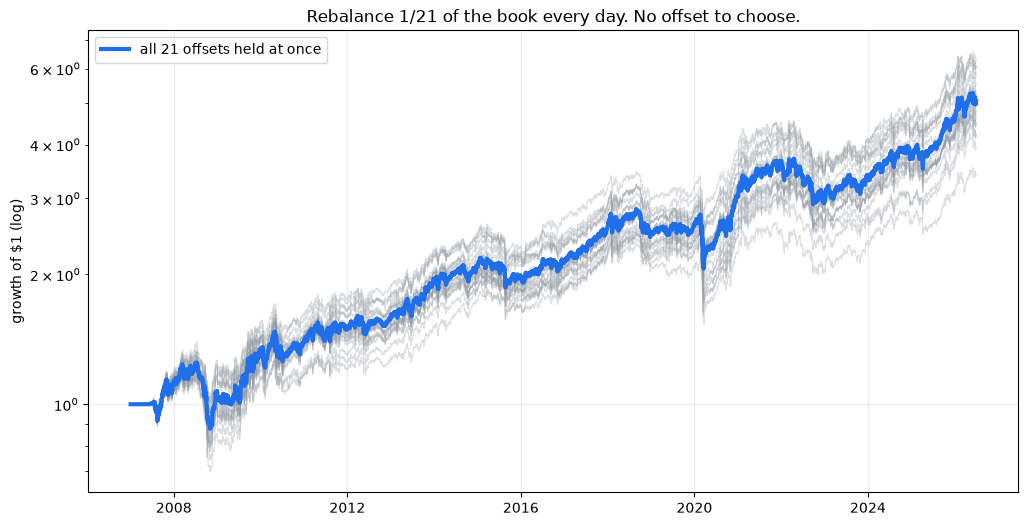

blended:               CAGR +8.66%, Sharpe 0.65, maxDD -29.8%
average single offset: CAGR +8.54%, Sharpe 0.62, maxDD -32.1%


In [7]:
ov = st.overlapping_portfolios(px, mom_rule(), 21, 5.0, cash)
fig, ax = plt.subplots(figsize=(12, 6))
for off in curves.columns:
    ax.plot(curves.index, curves[off], lw=0.8, alpha=0.3, color="#8b949e")
ax.plot(ov["value"].index, ov["value"], lw=3, color="#1f6feb",
        label="all 21 offsets held at once")
ax.set_yscale("log"); ax.set_ylabel("growth of $1 (log)"); ax.legend(fontsize=10)
ax.set_title("Rebalance 1/21 of the book every day. No offset to choose.")
plt.show()
print(f"blended:               CAGR {ov['cagr']:+.2%}, Sharpe {ov['sharpe']:.2f}, "
      f"maxDD {ov['max_dd']:.1%}")
print(f"average single offset: CAGR {ov['mean_variant_cagr']:+.2%}, "
      f"Sharpe {ov['mean_variant_sharpe']:.2f}, maxDD {ov['mean_variant_dd']:.1%}")

Not only is the timing luck gone — there is only one portfolio now — but the volatility is lower
and the drawdown shallower, because the twenty-one sleeves are not perfectly correlated with one
another. This is one of the rare cases where the careful thing to do is also the profitable
one.

## 6 · The verdict

**Signal: Confirmed.** The identical momentum rule, run at all **21 possible rebalance offsets** over 19 years, produced CAGRs from **+6.50% to +9.92%** — a spread of **3.42%** and a terminal-wealth ratio of **1.85×** between the luckiest and unluckiest start day. Nothing about the rule differed; only the day of the month it happened to trade. For scale, the rule's average edge over buy-and-hold was +0.29%/yr, so the luck is **11.6×** the edge, and 62% of the offsets beat the benchmark. A fixed-weight 60/40 shows far less — a spread of only 0.22% — because both variants hold the *same assets* and differ only in drift, while a ranking rule's variants hold different assets entirely. Any backtest of a selection rule that reports one rebalance date is reporting one draw from a distribution this wide.

**Tradability: Useful.** The fix is real and it is cheap. Running all 21 offsets at once — rebalancing 1/21 of the book each day — removes the dispersion by construction, and it does not cost return: the blended portfolio delivered **+8.66%/yr at a Sharpe of 0.65**, against the average single-offset variant's +8.54% and 0.62. It also cut volatility by 0.78% and improved the worst drawdown by 2.3% against the average variant, because the sleeves are imperfectly correlated with each other. The catch a practitioner should know: it is operationally more demanding — a daily trade instead of a monthly one — and section 6 confirms it preserves genuine signal rather than diluting it away.

## 7 · Going further \U0001F6AA

- **Check your own backtests.** Any rule that *selects* is exposed. Rerun it at every offset
  before believing the headline number.
- **Report the range, not the point.** A shaded band across offsets is more honest than a single
  line and costs nothing to produce.
- **Jegadeesh & Titman did this in 1993.** The original momentum paper used overlapping
  portfolios for precisely this reason. The practice got dropped somewhere along the way.